# ==========================================
# Enerji Perakende Veri Analizi
# NOTEBOOK 02 — Veri Görselleştirme
# ==========================================

Bu notebook'ta:

- İlçe bazlı tüketim karşılaştırmaları yapılmıştır.
- Hesap sınıfı dağılımları görselleştirilmiştir.
- Aylık tüketim trendleri analiz edilmiştir.
- Segment bazlı grafikler oluşturulmuştur.

Amaç: Veriyi görsel olarak analiz ederek örüntüleri ve farklılıkları ortaya çıkarmak.

In [1]:
import pandas as pd

from data_loader import load_data
df_tahsilat, df_tahsilat_1, df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2 = load_data(verbose=False)

print("Veriler başarıyla yüklendi.")

df_all = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

df_all.shape

Veriler başarıyla yüklendi.


(1185698, 10)

In [ ]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(f"{OUTPUT_DIR}/{name}.png",
                dpi=300,
                bbox_inches="tight")

print("Output klasörü hazır:", OUTPUT_DIR)

Output klasörü hazır: ../outputs


In [3]:
df_all['mali_yil_donem'] = pd.to_datetime(df_all['mali_yil_donem'])
df_all['ay'] = df_all['mali_yil_donem'].dt.month

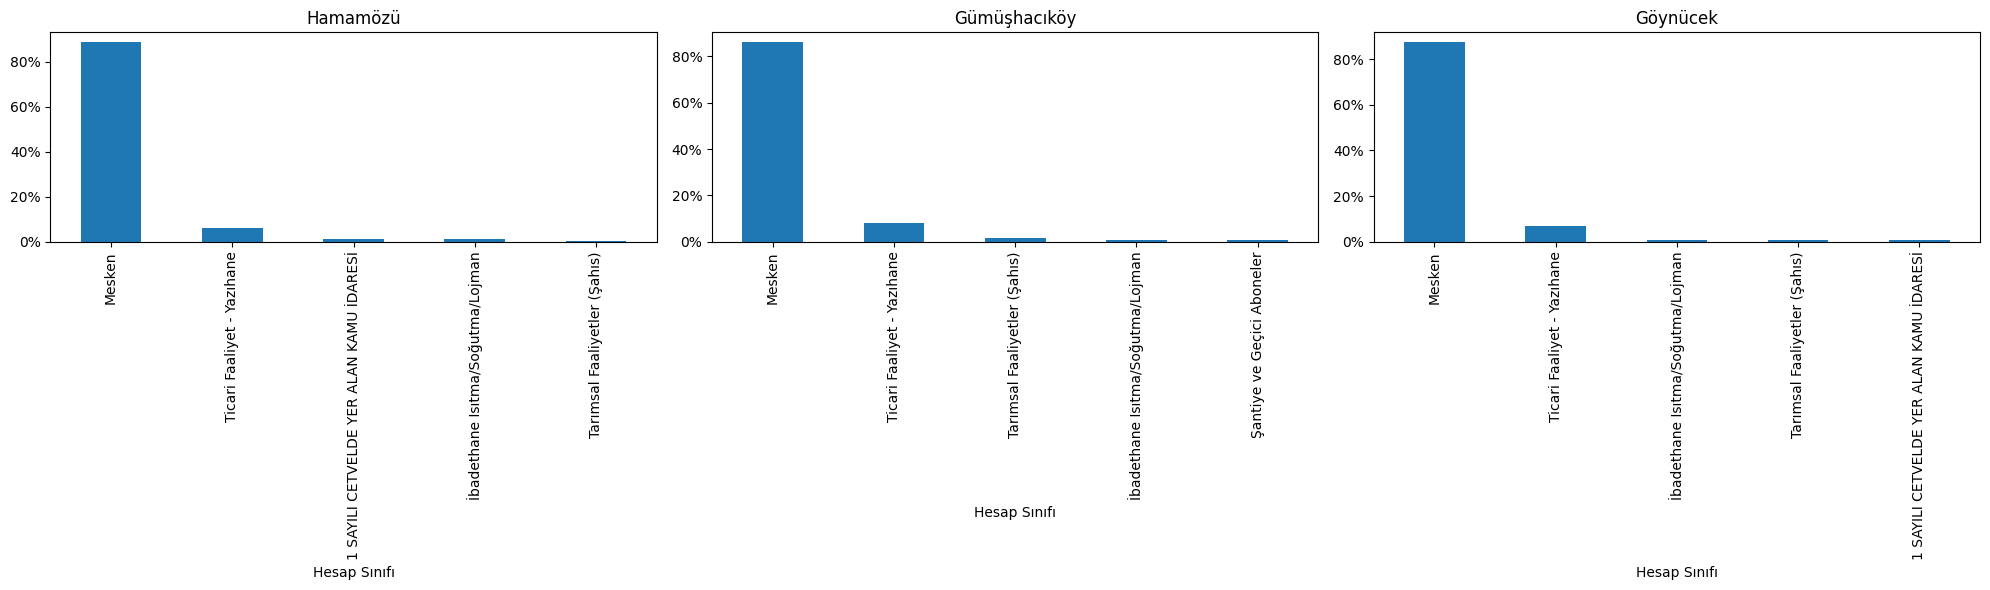

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Hamamözü
df_tahakkuk['Hesap Sınıfı'].value_counts(normalize=True).head(5).plot(
    kind='bar',
    ax=axes[0],
    title='Hamamözü'
)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Gümüşhacıköy
df_tahakkuk_1['Hesap Sınıfı'].value_counts(normalize=True).head(5).plot(
    kind='bar',
    ax=axes[1],
    title='Gümüşhacıköy'
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Göynücek
df_tahakkuk_2['Hesap Sınıfı'].value_counts(normalize=True).head(5).plot(
    kind='bar',
    ax=axes[2],
    title='Göynücek'
)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/hesap_sinifi_ilce_karsilastirma.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

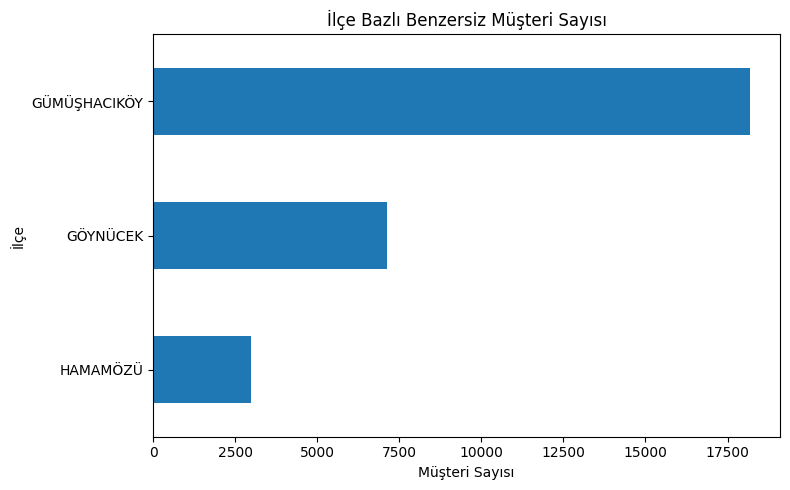

In [7]:
plt.figure(figsize=(8,5))
musteri_sayisi.plot(kind="barh")

plt.title("İlçe Bazlı Benzersiz Müşteri Sayısı")
plt.xlabel("Müşteri Sayısı")
plt.ylabel("İlçe")

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/ilce_bazli_musteri_sayisi.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [8]:
# Tüm sütun isimlerindeki boşlukları temizle
df_all.columns = df_all.columns.str.strip()

# Sütun isimlerinin tam listesini gör (Buradaki isimleri kopyalayıp koda yapıştır)
print(df_all.columns.tolist())

['il', 'ilce', 'sozlesme_hesap_no', 'mali_yil_donem', 'fatura_tarihi', 'kayit_tarihi', 'vade_tarihi', 'hesap_sinifi', 'Hesap Sınıfı', 'kwh', 'ay']


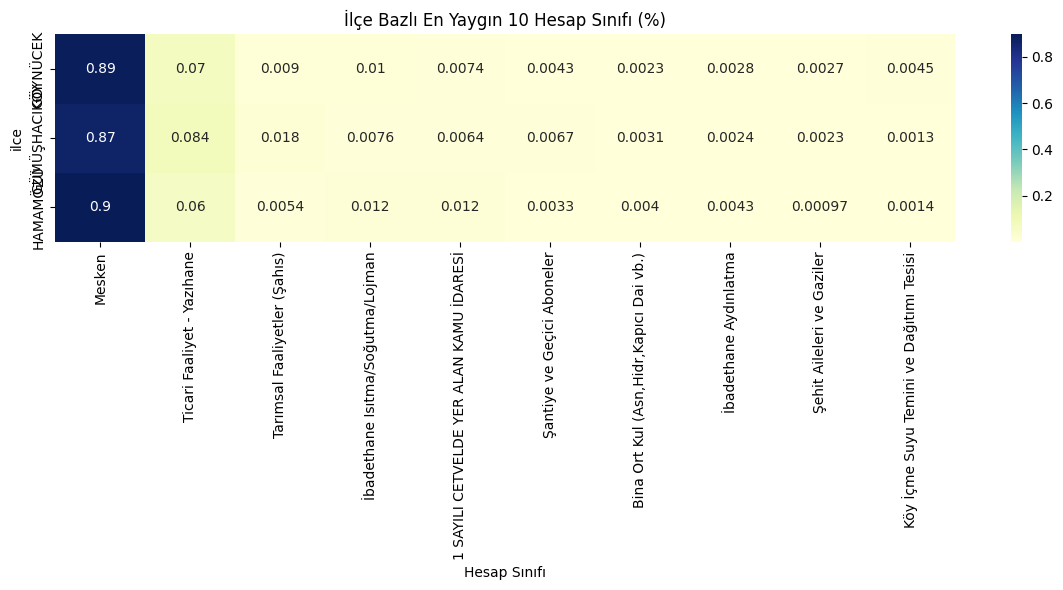

In [10]:
import seaborn as sns

top_classes = df_all["Hesap Sınıfı"].value_counts().head(10).index

heatmap_data = pd.crosstab(
    df_all["ilce"],
    df_all["Hesap Sınıfı"]
)

heatmap_data = heatmap_data[top_classes]
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True)

plt.title("İlçe Bazlı En Yaygın 10 Hesap Sınıfı (%)")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/ilce_hesap_sinifi_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Bulgular: İlçe Bazlı En Yaygın 10 Hesap Sınıfı

Isı haritası, ilçelerdeki ilk 10 hesap sınıfının dağılımını daha detaylı
şekilde karşılaştırma imkânı sunmaktadır.

- Üç ilçede de **Mesken** kategorisi açık ara baskındır (%87–90 aralığında).
  Bu durum, enerji talebinin büyük ölçüde konut kaynaklı olduğunu
  göstermektedir.

- **Ticari Faaliyet (Yazıhane)** kategorisi Gümüşhacıköy’de
  (%8.4) diğer ilçelere kıyasla daha yüksektir.
  Bu durum, ilçenin ticari yoğunluğunun görece daha fazla olduğuna
  işaret etmektedir.

- **Tarımsal Faaliyetler (Şahıs)** oranı Gümüşhacıköy’de
  (%1.8) diğer ilçelere göre daha belirgindir.
  Bu durum mevsimsel tüketim artışlarını açıklayan bir faktör olabilir.

- Hamamözü’nde mesken oranı en yüksek seviyededir (%90).
  Ticari ve tarımsal abonelerin düşük olması,
  ilçedeki ortalama tüketim değerlerinin daha düşük ve daha stabil
  olmasını açıklayabilir.

- Göynücek ilçesi ise mesken ağırlıklı bir yapı göstermekte,
  ancak ticari oran açısından Gümüşhacıköy’ün gerisinde kalmaktadır.

### Analitik Çıkarım

Hesap sınıfı kompozisyonu, ilçeler arasındaki tüketim farklarını
açıklamada kritik bir değişkendir. Ticari ve tarımsal abonelerin
yoğun olduğu bölgelerde ortalama tüketim değerlerinin daha yüksek
olması beklenmektedir. Bu nedenle, ilçe bazlı enerji talep
projeksiyonlarında müşteri segment kompozisyonu dikkate alınmalıdır.

In [11]:
df_all['mali_yil_donem'] = pd.to_datetime(df_all['mali_yil_donem'])
df_all['ay'] = df_all['mali_yil_donem'].dt.month

In [12]:
monthly_avg = (
    df_all
    .groupby(['ilce','ay'])['kwh']
    .mean()
    .reset_index()
)

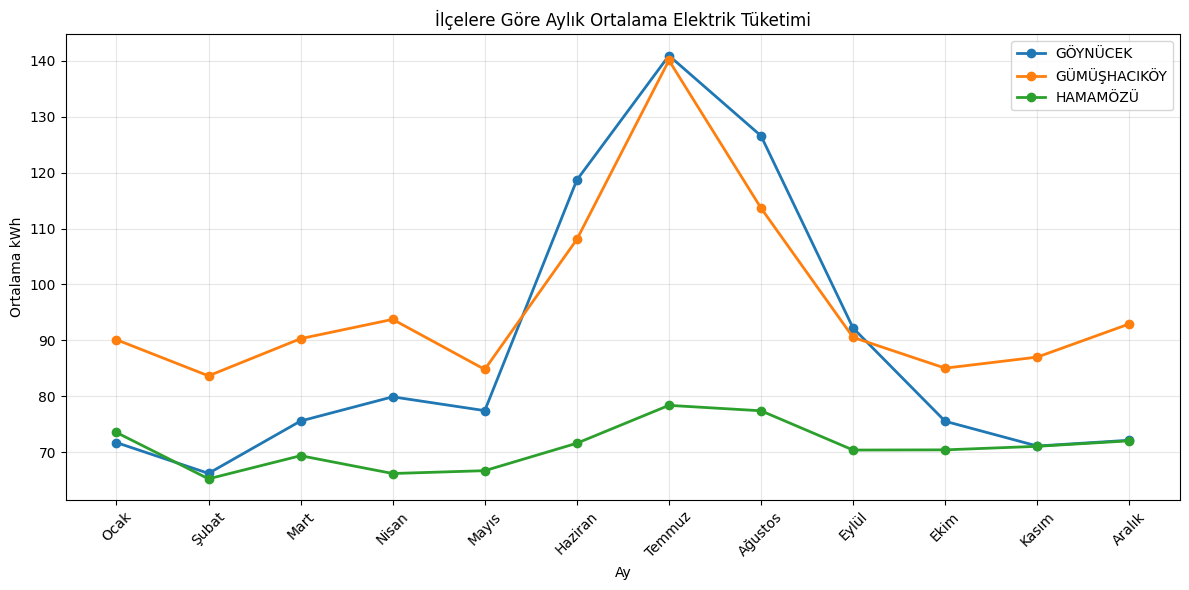

In [13]:
import matplotlib.pyplot as plt

# Ay isimleri
ay_isimleri = [
    "Ocak", "Şubat", "Mart", "Nisan", "Mayıs", "Haziran",
    "Temmuz", "Ağustos", "Eylül", "Ekim", "Kasım", "Aralık"
]

plt.figure(figsize=(12,6))

for ilce in monthly_avg['ilce'].unique():
    subset = monthly_avg[monthly_avg['ilce'] == ilce]
    plt.plot(subset['ay'], subset['kwh'],
             marker='o', linewidth=2, label=ilce)

plt.xlabel("Ay")
plt.ylabel("Ortalama kWh")
plt.title("İlçelere Göre Aylık Ortalama Elektrik Tüketimi")

plt.xticks(range(1,13), ay_isimleri, rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/mevsimsel_tuketim.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Bulgular: Mevsimsel Elektrik Tüketim Trendleri

- Üç ilçede de tüketim yaz aylarında belirgin şekilde artmaktadır. Özellikle **Temmuz ayı tüm ilçelerde zirve noktasıdır.**

- GÖYNÜCEK ve GÜMÜŞHACIKÖY ilçelerinde Haziran–Ağustos döneminde keskin bir artış gözlemlenmektedir. Bu artış, tarımsal sulama faaliyetleri, ticari yoğunluk ve yaz aylarında artan soğutma ihtiyacı ile ilişkili olabilir.

- HAMAMÖZÜ ilçesinde tüketim yıl boyunca daha düşük ve daha stabil seyretmektedir. Yaz dönemindeki artış diğer ilçelere kıyasla sınırlıdır.

- Temmuz ayında GÖYNÜCEK ve GÜMÜŞHACIKÖY yaklaşık 140 kWh seviyesine ulaşırken, HAMAMÖZÜ yaklaşık 78 kWh seviyesinde kalmaktadır. Bu fark ilçelerin ekonomik yapılarının farklı olduğuna işaret etmektedir.

### İş Perspektifi

- Yaz ayları talep zirvesi dönemidir ve kapasite planlaması açısından kritik öneme sahiptir.
- İlçelere özel enerji yönetim stratejileri geliştirilebilir.
- Ticari ve tarımsal abonelerin yoğun olduğu ilçelerde mevsimsel yük artışı daha belirgindir.

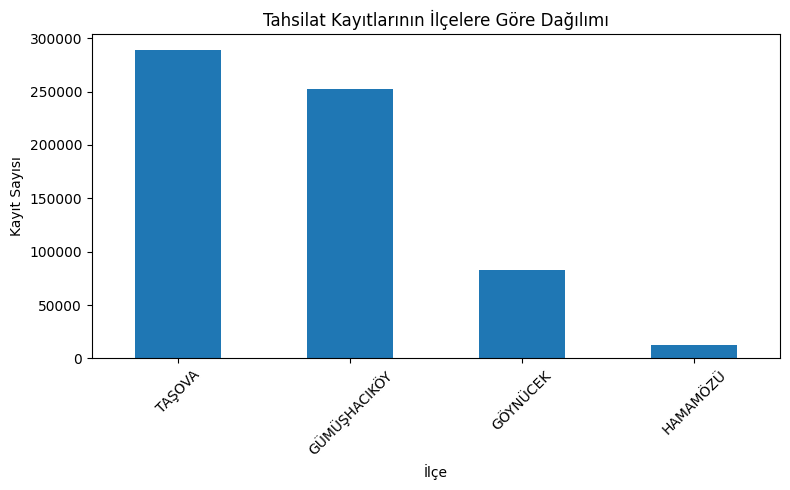

In [30]:
# İlçe Bazlı Tahsilat Dağılımı
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_tahsilat['İlçe'].value_counts().plot(
    kind='bar'
)

plt.title("Tahsilat Kayıtlarının İlçelere Göre Dağılımı")
plt.xlabel("İlçe")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/tahsilat_ilce_dagilimi.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


### Bulgular: İlçe Bazlı Tahsilat Dağılımı

- Tahsilat kayıtları en yüksek Taşova ilçesinde gerçekleşmiştir.
- Bu durum, tahsilat verisinin yalnızca analiz edilen üç ilçeyi değil, daha geniş bir bölgeyi kapsadığını göstermektedir.
- Gümüşhacıköy müşteri sayısında yüksek olmasına rağmen tahsilat dağılımında Taşova'nın gerisinde kalmaktadır.
- Hamamözü ilçesi hem müşteri sayısı hem de tahsilat kayıtları açısından daha düşük yoğunluk göstermektedir.

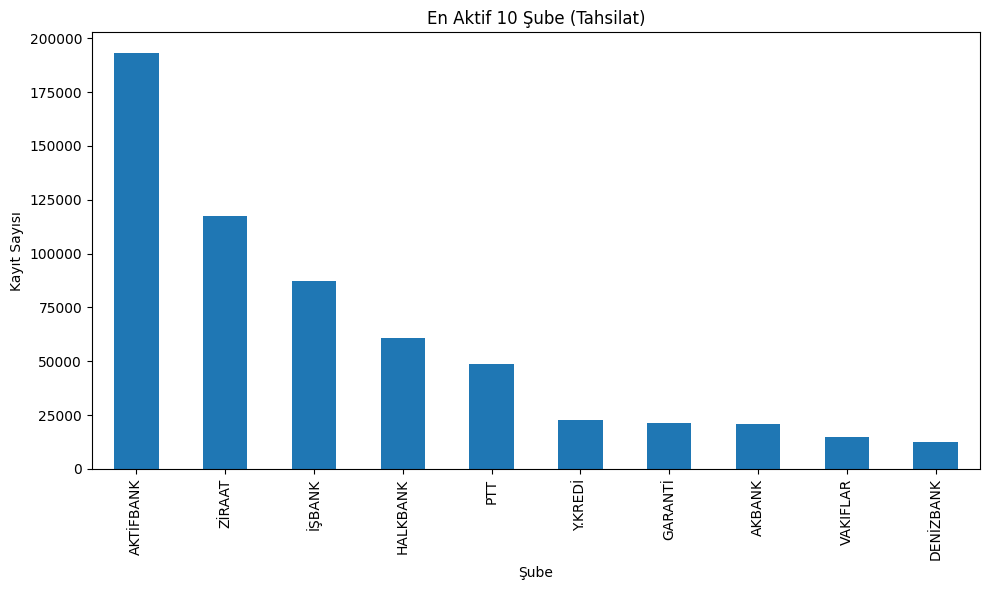

In [ ]:
# Şube Bazlı Tahsilat Dağılımı
plt.figure(figsize=(10,6))

df_tahsilat['Şube'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("En Aktif 10 Şube (Tahsilat)")
plt.xlabel("Şube")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/tahsilat_sube_dagilimi.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Bulgular: Şube Bazlı Tahsilat Dağılımı

- Tahsilat işlemlerinin büyük kısmı belirli bankalar üzerinden gerçekleştirilmektedir.
- AKTİFBANK açık ara en yoğun tahsilat yapılan kurumdur.
- Bu durum ödeme kanalı tercihlerinin dijital/banka ağırlıklı olduğunu göstermektedir.
- Nakit tahsilatın düşük olması operasyonel maliyet açısından olumlu bir göstergedir.

In [18]:
df_tahsilat_1.columns

Index(['Mali yıl/dönem', 'İl', 'İlçe', 'Söz.hsp.(bağımsız)', 'Hesap Sınıfı',
       'Tahakkuk Tutar', 'Son Ödeme Tarihinden Önceki Tahsilat',
       'Son Ödeme Tarihindeki Tahsilat', 'Son Ödeme (1)', 'Son Ödeme (2)',
       'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)',
       'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
       'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)',
       'Son Ödeme (150-180)', 'Son Ödeme (180+)'],
      dtype='object')

In [19]:
# -----------------------------
# Fatura Bazlı Zamanında & Geç Ödeme Hesaplama
# -----------------------------

# Zamanında ödeme var mı? (satır bazlı kontrol)
on_time_flag = (
    df_tahsilat_1['Son Ödeme Tarihinden Önceki Tahsilat'].notna() |
    df_tahsilat_1['Son Ödeme Tarihindeki Tahsilat'].notna()
)

# Geç ödeme kolonlarını seçiyoruz
late_cols = [col for col in df_tahsilat_1.columns if "Son Ödeme (" in col]

# Satır bazlı geç ödeme kontrolü
late_flag = df_tahsilat_1[late_cols].notna().any(axis=1)

# Count hesaplama
on_time_count = on_time_flag.sum()
late_count = late_flag.sum()

total_fatura = len(df_tahsilat_1)

print("Toplam Fatura:", total_fatura)
print("Zamanında Ödenen Fatura:", on_time_count)
print("Geç Ödenen Fatura:", late_count)

on_time_ratio = on_time_count / total_fatura * 100
late_ratio = late_count / total_fatura * 100

print(f"Zamanında Ödeme Oranı: %{on_time_ratio:.2f}")
print(f"Geç Ödeme Oranı: %{late_ratio:.2f}")

Toplam Fatura: 917632
Zamanında Ödenen Fatura: 789588
Geç Ödenen Fatura: 249487
Zamanında Ödeme Oranı: %86.05
Geç Ödeme Oranı: %27.19


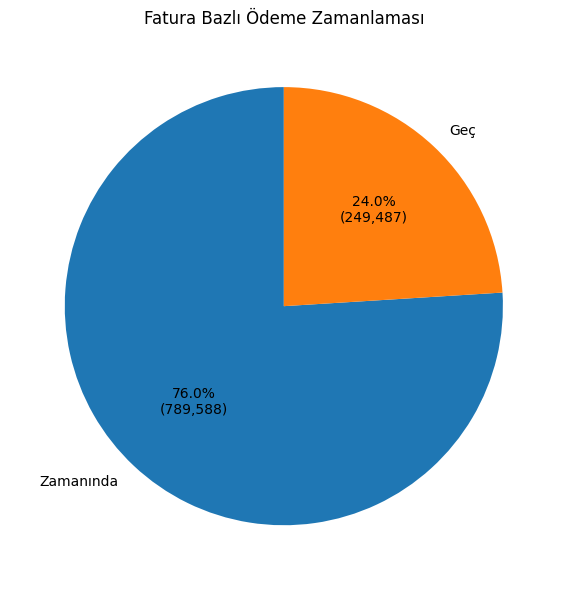

In [ ]:
import matplotlib.pyplot as plt

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"
    return my_format

plt.figure(figsize=(6,6))

values = [on_time_count, late_count]

plt.pie(
    values,
    labels=["Zamanında", "Geç"],
    autopct=autopct_format(values),
    startangle=90
)

plt.title("Fatura Bazlı Ödeme Zamanlaması")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/odeme_zamanlamasi_pie.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Bulgular: Fatura Bazlı Ödeme Zamanlaması Analizi

- Toplam 917,632 fatura incelenmiştir.
- Faturaların %86.05’i (789,588 adet) son ödeme tarihinde veya öncesinde tahsil edilmiştir.
- Faturaların %27.19’u (249,487 adet) son ödeme tarihinden sonra en az bir kez geç ödeme içermektedir.

### Önemli Not

Zamanında ve geç ödeme oranlarının toplamı %100’ü aşmaktadır. Bunun nedeni, bazı faturaların hem zamanında hem de geç ödeme içerebilmesidir (kısmi ödeme durumu).

Bu durum şunu göstermektedir:
- Müşterilerin büyük çoğunluğu faturalarını zamanında ödemektedir.
- Ancak yaklaşık dörtte bir oranında fatura, en az bir kez gecikmeli ödeme davranışı göstermektedir.

### İş Perspektifi

- %86 zamanında ödeme oranı güçlü bir tahsilat performansına işaret etmektedir.
- %27 oranında geç ödeme davranışı ise risk segmentasyonu için önemli bir göstergedir.
- Geç ödeme davranışı gösteren müşteri grupları analiz edilerek erken uyarı ve teşvik mekanizmaları geliştirilebilir.

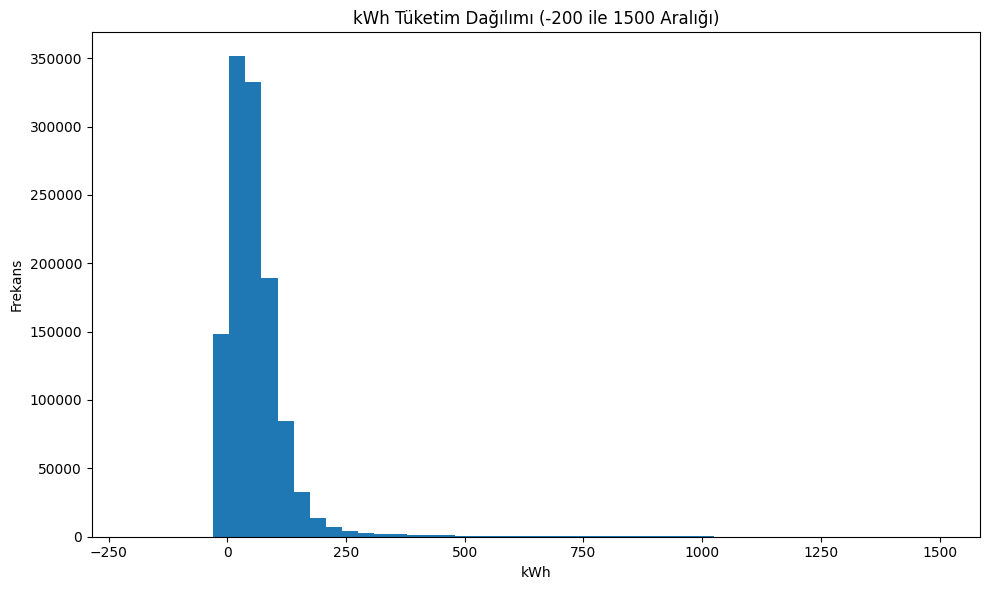

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_all['kwh'],
    bins=50,
    range=(-200, 1500)
)

plt.title("kWh Tüketim Dağılımı (-200 ile 1500 Aralığı)")
plt.xlabel("kWh")
plt.ylabel("Frekans")

plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/kwh_tuketim_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [24]:
# Q1 ve Q3 hesaplama
Q1 = df_all['kwh'].quantile(0.25)
Q3 = df_all['kwh'].quantile(0.75)

IQR = Q3 - Q1

# Outlier sınırları
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Alt sınır:", lower_bound)
print("Üst sınır:", upper_bound)

Alt sınır: -74.97499999999998
Üst sınır: 172.98499999999999


In [25]:
outliers = df_all[(df_all['kwh'] < lower_bound) | (df_all['kwh'] > upper_bound)]

print("Toplam Outlier Sayısı:", len(outliers))

Toplam Outlier Sayısı: 48554


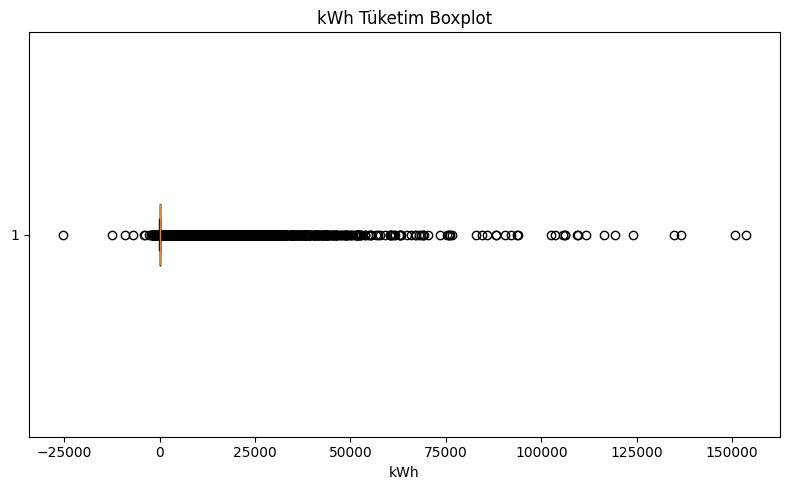

In [34]:
plt.figure(figsize=(8,5))

plt.boxplot(df_all['kwh'], vert=False)

plt.title("kWh Tüketim Boxplot")
plt.xlabel("kWh")

plt.tight_layout()

# 🔥 Önce kaydet
plt.savefig(f"{OUTPUT_DIR}/kwh_tuketim_boxplot.png",
            dpi=300,
            bbox_inches="tight")

# 🔥 Sonra göster
plt.show()

### kWh Tüketim Dağılımı ve Aykırı Değer Analizi

IQR yöntemi kullanılarak alt sınır -74.97 kWh, üst sınır ise 172.98 kWh olarak hesaplanmıştır.
Bu sınırların dışında kalan toplam 48,554 gözlem aykırı değer olarak belirlenmiştir.
Bu değerler veri setinin yaklaşık %4'ünü oluşturmaktadır.

Boxplot grafiği, dağılımın sağa çarpık olduğunu ve çok sayıda yüksek tüketim değerinin bulunduğunu göstermektedir.
Negatif tüketim değerleri ise sayaç düzeltmeleri veya teknik kayıt işlemleri ile ilişkili olabilir.

Tüketimlerin ana yoğunluğunu daha net gösterebilmek amacıyla histogram 0–300 kWh aralığında çizilmiştir.
Bu görselleştirme, tüketimlerin büyük çoğunluğunun düşük aralıkta (özellikle 0–200 kWh) yoğunlaştığını ortaya koymaktadır.
Ancak az sayıda yüksek tüketim değeri dağılımın sağ kuyruğunu oluşturmaktadır.

Genel olarak dağılım sağa çarpıktır (right-skewed) ve aşırı yüksek tüketimler ortalama değeri yukarı çekmektedir.
Bu nedenle bazı analizlerde medyan değerin kullanılması daha temsil edici olabilir.

## Notebook_02 Genel Değerlendirme

Bu notebook kapsamında enerji tüketim ve tahsilat verileri
görselleştirme teknikleri kullanılarak çok boyutlu biçimde
incelenmiştir. Amaç, verinin dağılım yapısını, ilçeler arası
farklılıkları, müşteri profil kompozisyonunu ve ödeme davranışındaki
örüntüleri grafikler aracılığıyla görünür kılmaktır.

kWh tüketim dağılımı analizi, verinin belirgin şekilde sağa çarpık
(right-skewed) bir yapıya sahip olduğunu göstermiştir. Az sayıda
yüksek tüketim değeri ortalamayı yukarı çekmekte ve dağılımın
uzun bir sağ kuyruğa sahip olmasına neden olmaktadır. Bu nedenle
özellikle segment analizlerinde medyan değerin daha temsil edici
olabileceği görülmüştür.

Fatura bazlı ödeme zamanlaması incelendiğinde genel tahsilat
performansının güçlü olduğu (%86 zamanında ödeme) gözlemlenmiştir.
Bununla birlikte yaklaşık dörtte bir oranında faturada en az bir
gecikmeli ödeme davranışı bulunması, risk segmentasyonu ve erken
uyarı mekanizmalarının önemini ortaya koymaktadır.

İlçe bazlı analizler, tüketim farklılıklarının yalnızca müşteri
sayısından değil, müşteri kompozisyonundan da kaynaklandığını
göstermiştir. Hesap sınıfı dağılımı incelendiğinde tüm ilçelerde
mesken aboneleri baskın olmakla birlikte, ticari ve tarımsal
abonelerin oranındaki farklılıklar ilçelerin ekonomik yapısının
tüketime doğrudan yansıdığını göstermektedir. Özellikle ticari
faaliyet oranı yüksek olan ilçelerde ortalama tüketimin daha
yüksek olması bu ilişkiyi desteklemektedir.

Mevsimsel analizler üç ilçede de yaz döneminde belirgin tüketim
artışı olduğunu göstermiştir. Temmuz ayı tüm ilçelerde zirve
noktasıdır. Bu durum, kapasite planlaması, yük yönetimi ve
talep tahminleme süreçleri açısından kritik bir içgörü sunmaktadır.

Genel olarak Notebook_02, verinin dağılımsal yapısını,
bölgesel farklılıklarını ve zaman boyutundaki davranışını
ortaya koyarak Notebook_03’te gerçekleştirilen segmentasyon,
eşitsizlik analizi ve stratejik çıkarımlar için sağlam bir
analitik zemin hazırlamıştır.